In [ ]:
! pip install cppyy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 11.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached cppyy_backend-1.15.3-py2.py3-none-linux_x86_64.whl
  Using cached cppyy_cling-6.32.8-py2.py3-none-manylinux2014_x86_64.whl.metadata (2.2 kB)
Using cached cppyy_cling-6.32.8-py2.py3-none-manylinux2014_x86_64.whl (47.8 MB)
  Created wheel for cppyy: filename=cppyy-3.5.0-py3-none-any.whl size=16907005 sha256=08ac7bbc16ef34dd75129d24ace3ad4b3304523ed1233b136b14405ec559b5c2
  Stored in directory: /root/.cache/pip/wheels/aa/27/7d/0d09d1ef70849c6f2db15a9839dae565f1f97a330e5a0dc9af
  Created wheel for CPyCppyy: filename=cpycppyy-1.13.0-cp312-cp312-linux_x86_64.whl size=4729280 sha256=7816b87c

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import math
import cppyy

# includi l’header di EcoMug
cppyy.include("/content/drive/MyDrive/Terzo anno/Tirocinio/EcoMug/EcoMug.h")
# importa le classi dallo spazio dei nomi globale
from cppyy.gbl import EcoMug, EMMultiGen, EMUnits

# NON TOCCARE: definizione errori assoluti (errA, errB), covarianza (cov) e errore relativo su un rapporto
class ErrorsUtility:
    @staticmethod
    def error_ratio(A, B, errA, errB, cov=0.0):
        f = A / B
        return abs(f) * math.sqrt((errA / A)**2 + (errB / B)**2 - 2*cov/(A*B))

#NON TOCCARE: definizione spettro angolare J
def J(p, theta):
    A = 1400 * p**(-2.7)
    B = 1.0 / (1.0 + 1.1 * p * math.cos(theta) / 115.0)
    C = 0.054 / (1.0 + 1.1 * p * math.cos(theta) / 850.0)
    return A * (B + C)

#DA DEFINIRE: per modificare i punti andare in suite_no1
class PlaneDet:
    def __init__(self, p1: np.ndarray, p2: np.ndarray, p3: np.ndarray):
        self.mP1 = p1
        self.mP2 = p2
        self.mP3 = p3

# NB: selezionare il piano (xy,yz o xz) in funzione dell'allineamento dei punti
    def get_area(self) -> float:
        dx = np.max([self.mP1[0], self.mP2[0], self.mP3[0]]) - np.min([self.mP1[0], self.mP2[0], self.mP3[0]])
        dy = np.max([self.mP1[1], self.mP2[1], self.mP3[1]]) - np.min([self.mP1[1], self.mP2[1], self.mP3[1]])
        return dx * dy

    #def get_area(self) -> float:
        #dx = np.max([self.mP1[0], self.mP2[0], self.mP3[0]]) - np.min([self.mP1[0], self.mP2[0], self.mP3[0]])
        #dz = np.max([self.mP1[2], self.mP2[2], self.mP3[2]]) - np.min([self.mP1[2], self.mP2[2], self.mP3[2]])
        #return dx * dz

    #def get_area(self) -> float:
        #dy = np.max([self.mP1[1], self.mP2[1], self.mP3[1]]) - np.min([self.mP1[1], self.mP2[1], self.mP3[1]])
        #dz = np.max([self.mP1[2], self.mP2[2], self.mP3[2]]) - np.min([self.mP1[2], self.mP2[2], self.mP3[2]])
        #return dy * dz

# NB: selezionare la parte finale del codice in funzione dell'orientamento del piano
    def is_crossed(self, Ro: np.ndarray, Po: np.ndarray) -> bool:
        num = np.array([
            [1.0,        1.0,        1.0,       1.0],
            [self.mP1[0], self.mP2[0], self.mP3[0], Ro[0]],
            [self.mP1[1], self.mP2[1], self.mP3[1], Ro[1]],
            [self.mP1[2], self.mP2[2], self.mP3[2], Ro[2]],
        ])
        den = np.array([
            [1.0,        1.0,        1.0,       0.0],
            [self.mP1[0], self.mP2[0], self.mP3[0], Po[0]],
            [self.mP1[1], self.mP2[1], self.mP3[1], Po[1]],
            [self.mP1[2], self.mP2[2], self.mP3[2], Po[2]],
        ])
        det_den = np.linalg.det(den)
        if abs(det_den) < 1e-9:
            return False
        t = -np.linalg.det(num) / det_den
        intercept = Ro + t * Po
        x_min, x_max = sorted([self.mP1[0], self.mP2[0]])
        y_min, y_max = sorted([self.mP2[1], self.mP3[1]])
        return (x_min <= intercept[0] <= x_max) and (y_min <= intercept[1] <= y_max)

        #intercept = Ro + t * Po
        #x_min, x_max = sorted([self.mP1[0], self.mP2[0]])
        #z_min, z_max = sorted([self.mP1[2], self.mP3[2]])
        #return (x_min <= intercept[0] <= x_max) and (z_min <= intercept[2] <= z_max)

        #intercept = Ro + t * Po
        #y_min, y_max = sorted([self.mP1[1], self.mP2[1]])
        #z_min, z_max = sorted([self.mP1[2], self.mP3[2]])
        #return (y_min <= intercept[1] <= y_max) and (z_min <= intercept[2] <= z_max)



def suite_no1(number_of_events: int):
    # Inizializzazione generatori EcoMug
    genPlane = EcoMug()
    genPlane.SetUseSky()
    genPlane.SetSkySize((2000.0 * EMUnits.mm, 2000.0 * EMUnits.mm))
    genPlane.SetSkyCenterPosition((0.0 * EMUnits.mm, 0.0 * EMUnits.mm, 1.0 * EMUnits.mm))

    genHSphere = EcoMug()
    genHSphere.SetUseHSphere()
    genHSphere.SetHSphereRadius(2000.0 * EMUnits.mm)
    genHSphere.SetHSphereCenterPosition((0.0, 0.0, 0.0))

    # Definizione piano del rivelatore (XY) - (XZ) - (YZ)
    P1 = np.array([ 200.0 * EMUnits.mm, 100.0 * EMUnits.mm, 0.0 * EMUnits.mm])
    P2 = np.array([ 200.0 * EMUnits.mm, -100.0 * EMUnits.mm, 0.0 * EMUnits.mm])
    P3 = np.array([ -200.0 * EMUnits.mm, 100.0 * EMUnits.mm, 0.0 * EMUnits.mm])
    detector = PlaneDet(P1, P2, P3)

    # Liste per salvare gli angoli
    theta_plane = []
    theta_sphere = []
    phi_plane = []
    phi_sphere = []


    # Funzione interna per la generazione e il filtraggio dei muoni
    def run_generator(gen, number_of_events, detector, theta_list, phi_list):
        n_gen = n_good = 0
        while n_good < number_of_events:
            gen.Generate()
            n_gen += 1

            pos = np.array(gen.GetGenerationPosition())
            ptot = gen.GetGenerationMomentum()
            theta = gen.GetGenerationTheta()
            phi = gen.GetGenerationPhi()

            Ro = pos
            Po = ptot * np.array([
                math.sin(theta) * math.cos(phi),
                math.sin(theta) * math.sin(phi),
                math.cos(theta)
            ])

            if detector.is_crossed(Ro, Po):
              n_good += 1
              theta_list.append(theta)
              phi_list.append(phi)


        return n_gen, n_good

    # --- Generazione dal piano ---
    n_plane, good_plane = run_generator(genPlane, number_of_events, detector, theta_plane, phi_plane)
    print("\n--- Generation from horizontal plane ---")
    print(f"number of generated muons                   = {n_plane}")
    print(f"number of muons through the detector        = {good_plane}")
    print(f"number of gen muons/generation surface [m2] = {n_plane / (genPlane.GetGenSurfaceArea() / EMUnits.m2)}")
    print(f"Estimated time [s]                          = {genPlane.GetEstimatedTime(n_plane)}")

    # --- Generazione dalla semisfera ---
    n_sphere, good_sphere = run_generator(genHSphere, number_of_events, detector, theta_sphere, phi_sphere)
    print("\n--- Generation from half-sphere ---")
    print(f"number of generated muons                   = {n_sphere}")
    print(f"number of muons through the detector        = {good_sphere}")
    print(f"number of gen muons/generation surface [m2] = {n_sphere / (genHSphere.GetGenSurfaceArea() / EMUnits.m2)}")
    print(f"Estimated time [s]                          = {genHSphere.GetEstimatedTime(n_sphere)}")

    # --- Calcolo rate ---
    rate = (good_sphere / detector.get_area()) / (n_sphere / genHSphere.GetGenSurfaceArea())
    print(f"\nhorizontal to half-spherical rate           = {rate}\n")

    # --- Salvataggio angoli ---
    np.savetxt("zenith_plane.txt", theta_plane)
    np.savetxt("zenith_sphere.txt", theta_sphere)
    np.savetxt("azimuth_plane.txt", phi_plane)
    np.savetxt("azimuth_sphere.txt", phi_sphere)



# … (implementazione di suite_no2, suite_no3, suite_no4, test_suite identica a prima) …

def test_suite(suite_no: int, number_of_events: int):
    if   suite_no == 1: suite_no1(number_of_events)
    elif suite_no == 2: suite_no2(number_of_events)
    elif suite_no == 3: suite_no3(number_of_events)
    elif suite_no == 4: suite_no4(number_of_events)
    else:
        print("Unknown suite number! Valid values are 1–4.")

#NB: Variare il numero di muoni desiderati
if __name__ == "__main__":
    import sys
    if len(sys.argv) != 3:
        print("Usage: python test_ecomug.py <suite_no> <number_of_events>")
    else:
        test_suite(int(1), int(200))

KeyboardInterrupt: 

In [ ]:
import numpy as np
import math
import cppyy

# --------------------------------------------
# Includi l’header di EcoMug
# --------------------------------------------
cppyy.include("/content/drive/MyDrive/Terzo anno/Tirocinio/EcoMug/EcoMug.h")
from cppyy.gbl import EcoMug, EMMultiGen, EMUnits

# --------------------------------------------
# Utility errori e spettro (immutati)
# --------------------------------------------
class ErrorsUtility:
    @staticmethod
    def error_ratio(A, B, errA, errB, cov=0.0):
        f = A / B
        return abs(f) * math.sqrt((errA / A)**2 + (errB / B)**2 - 2*cov/(A*B))

def J(p, theta):
    A = 1400 * p**(-2.7)
    B = 1.0 / (1.0 + 1.1 * p * math.cos(theta) / 115.0)
    C = 0.054 / (1.0 + 1.1 * p * math.cos(theta) / 850.0)
    return A * (B + C)

# --------------------------------------------
# Rivelatore rettangolare, assi-allineato su XY/XZ/YZ
# --------------------------------------------
class PlaneDet:
    """
    Rettangolo assi-allineato, definito da 3 vertici consecutivi (non diagonali).
    plane: "xy", "xz" o "yz".
    Ottimizzato: intersezione raggio-piano con formula chiusa; limiti min/max precomputati.
    """
    def __init__(self, p1: np.ndarray, p2: np.ndarray, p3: np.ndarray, plane: str = "xy"):
        self.mP1 = np.asarray(p1, dtype=float)
        self.mP2 = np.asarray(p2, dtype=float)
        self.mP3 = np.asarray(p3, dtype=float)
        self.plane = plane.lower()

        # Ricostruisci il 4° vertice (rettangolo):
        self.mP4 = self.mP1 + self.mP3 - self.mP2

        # Precalcola limiti assi-allineati a seconda del piano scelto
        xs = [self.mP1[0], self.mP2[0], self.mP3[0], self.mP4[0]]
        ys = [self.mP1[1], self.mP2[1], self.mP3[1], self.mP4[1]]
        zs = [self.mP1[2], self.mP2[2], self.mP3[2], self.mP4[2]]

        if self.plane == "xy":
            self.z0 = self.mP1[2]  # tutti i vertici devono condividere la stessa z
            self.x_min, self.x_max = min(xs), max(xs)
            self.y_min, self.y_max = min(ys), max(ys)
        elif self.plane == "xz":
            self.y0 = self.mP1[1]
            self.x_min, self.x_max = min(xs), max(xs)
            self.z_min, self.z_max = min(zs), max(zs)
        elif self.plane == "yz":
            self.x0 = self.mP1[0]
            self.y_min, self.y_max = min(ys), max(ys)
            self.z_min, self.z_max = min(zs), max(zs)
        else:
            raise ValueError('plane deve essere "xy", "xz" oppure "yz"')

    def get_area(self) -> float:
        if self.plane == "xy":
            dx = self.x_max - self.x_min
            dy = self.y_max - self.y_min
            return dx * dy
        elif self.plane == "xz":
            dx = self.x_max - self.x_min
            dz = self.z_max - self.z_min
            return dx * dz
        else:  # "yz"
            dy = self.y_max - self.y_min
            dz = self.z_max - self.z_min
            return dy * dz

def is_crossed(self, Ro: np.ndarray, Po: np.ndarray, plane="XY") -> bool:
    num = np.array([
        [1.0, 1.0, 1.0, 1.0],
        [self.mP1[0], self.mP2[0], self.mP3[0], Ro[0]],
        [self.mP1[1], self.mP2[1], self.mP3[1], Ro[1]],
        [self.mP1[2], self.mP2[2], self.mP3[2], Ro[2]],
    ])
    den = np.array([
        [1.0, 1.0, 1.0, 0.0],
        [self.mP1[0], self.mP2[0], self.mP3[0], Po[0]],
        [self.mP1[1], self.mP2[1], self.mP3[1], Po[1]],
        [self.mP1[2], self.mP2[2], self.mP3[2], Po[2]],
    ])
    det_den = np.linalg.det(den)
    if abs(det_den) < 1e-9:
        return False
    t = -np.linalg.det(num) / det_den
    intercept = Ro + t * Po

    if plane == "XY":
        x_min, x_max = sorted([self.mP1[0], self.mP2[0]])
        y_min, y_max = sorted([self.mP1[1], self.mP2[1]])
        return (x_min <= intercept[0] <= x_max) and (y_min <= intercept[1] <= y_max)
    elif plane == "XZ":
        x_min, x_max = sorted([self.mP1[0], self.mP2[0]])
        z_min, z_max = sorted([self.mP1[2], self.mP2[2]])
        return (x_min <= intercept[0] <= x_max) and (z_min <= intercept[2] <= z_max)
    elif plane == "YZ":
        y_min, y_max = sorted([self.mP1[1], self.mP2[1]])
        z_min, z_max = sorted([self.mP1[2], self.mP2[2]])
        return (y_min <= intercept[1] <= y_max) and (z_min <= intercept[2] <= z_max)


# --------------------------------------------
# Barra di progresso
# --------------------------------------------
try:
    from tqdm import tqdm
    _HAS_TQDM = True
except Exception:
    _HAS_TQDM = False
    def tqdm(iterable=None, total=None, desc=None, unit=None):
        # fallback minimale: passa-through
        if iterable is None:
            class Dummy:
                def __enter__(self): return self
                def __exit__(self, *a): pass
                def update(self, *a, **k): pass
            return Dummy()
        else:
            return iterable

# --------------------------------------------
# Suite 1: generazione + salvataggio angoli con batch
# --------------------------------------------
import numpy as np
from tqdm import tqdm

import numpy as np
import math
from tqdm import tqdm

class PlaneDet:
    def __init__(self, plane='XY', x_range=(0,1), y_range=(0,1), z_range=(0,1)):
        self.plane = plane.upper()
        self.x_min, self.x_max = x_range
        self.y_min, self.y_max = y_range
        self.z_min, self.z_max = z_range

    def is_crossed(self, pos, momentum):
        # pos: punto di partenza, momentum: vettore
        x, y, z = pos
        px, py, pz = momentum

        # Parametric line: L(t) = pos + t*momentum
        # Intersezione con il piano scelto
        if self.plane == 'XY':
            if pz == 0:
                return False
            t = -z / pz
            xi, yi = x + t*px, y + t*py
            return self.x_min <= xi <= self.x_max and self.y_min <= yi <= self.y_max
        elif self.plane == 'XZ':
            if py == 0:
                return False
            t = -y / py
            xi, zi = x + t*px, z + t*pz
            return self.x_min <= xi <= self.x_max and self.z_min <= zi <= self.z_max
        elif self.plane == 'YZ':
            if px == 0:
                return False
            t = -x / px
            yi, zi = y + t*py, z + t*pz
            return self.y_min <= yi <= self.y_max and self.z_min <= zi <= self.z_max
        else:
            raise ValueError("Piano non riconosciuto. Usa 'XY', 'XZ' o 'YZ'.")

def run_generator(gen, number_of_events, detector, theta_list, phi_list):
    n_good = 0
    pbar = tqdm(total=number_of_events, desc="Generating muons", ncols=100)
    while n_good < number_of_events:
        gen.Generate()
        pos = np.array(gen.GetGenerationPosition())
        ptot = gen.GetGenerationMomentum()
        theta = gen.GetGenerationTheta()
        phi = gen.GetGenerationPhi()
        Po = ptot * np.array([
            math.sin(theta) * math.cos(phi),
            math.sin(theta) * math.sin(phi),
            math.cos(theta)
        ])
        if detector.is_crossed(pos, Po):
            theta_list.append(theta)
            phi_list.append(phi)
            n_good += 1
            pbar.update(1)
    pbar.close()

def suite_no1(genPlane, genHSphere, number_of_events, plane='XY'):
    theta_plane, phi_plane = [], []
    theta_sphere, phi_sphere = [], []

    detector = PlaneDet(plane=plane)

    run_generator(genPlane, number_of_events, detector, theta_plane, phi_plane)
    run_generator(genHSphere, number_of_events, detector, theta_sphere, phi_sphere)

    # Ritorna i risultati
    return theta_plane, phi_plane, theta_sphere, phi_sphere



if __name__ == "__main__":
    # Esempio: piano XZ
    points = [
        np.array([0, 0, 0]),
        np.array([1, 0, 0]),
        np.array([0, 0, 1])
    ]
    suite_no1(points, number_of_events=5000)


# --------------------------------------------
# Placeholder per altre suite (se servono)
# --------------------------------------------
def suite_no2(number_of_events: int, **kwargs):
    print("suite_no2 non implementata in questa versione ottimizzata.")

def suite_no3(number_of_events: int, **kwargs):
    print("suite_no3 non implementata in questa versione ottimizzata.")

def suite_no4(number_of_events: int, **kwargs):
    print("suite_no4 non implementata in questa versione ottimizzata.")

def test_suite(suite_no: int, number_of_events: int, **kwargs):
    if   suite_no == 1: suite_no1(number_of_events, **kwargs)
    elif suite_no == 2: suite_no2(number_of_events, **kwargs)
    elif suite_no == 3: suite_no3(number_of_events, **kwargs)
    elif suite_no == 4: suite_no4(number_of_events, **kwargs)
    else:
        print("Unknown suite number! Valid values are 1–4.")

# --------------------------------------------
# Main: usa davvero gli argomenti della CLI
# Esempio:
#   python test_ecomug.py 1 200 xy
# --------------------------------------------
if __name__ == "__main__":
    # Esegui direttamente senza sys.argv
    test_suite(1, 5000)   # suite_no=1, number_of_events=200



TypeError: suite_no1() missing 1 required positional argument: 'genHSphere'

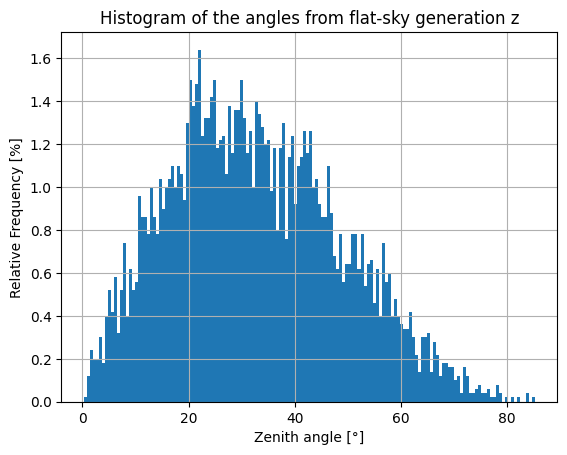

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dati e conversione in gradi
zangles_plane = np.loadtxt("angles_plane.txt")
GRADIz_piano = np.pi - zangles_plane
GRADIz_piano = np.degrees(GRADIz_piano)

# ==== FREQUENZE RELATIVE ====

# 1) Costruisco istogramma, ma mi prendo i dati numerici
conteggi, bin_edges = np.histogram(GRADIz_piano, bins=150)

# 2) Calcolo le frequenze relative dividendo per il numero totale
totale = len(GRADIz_piano)
frequenze_relative = (conteggi / totale) * 100

# 3) Calcolo il valore medio di ogni intervallo di bin per rappresentarlo sull'asse X
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# 4) Grafico frequenza relativa
plt.bar(bin_centers, frequenze_relative, width=(bin_edges[1]-bin_edges[0]))
plt.title('Histogram of the angles from flat-sky generation z')
plt.xlabel('Zenith angle [°]')
plt.ylabel('Relative Frequency [%]')
plt.grid(True)
plt.show()


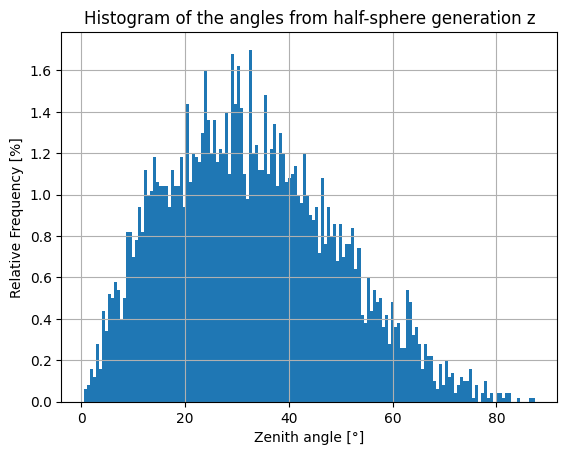

In [ ]:
# Caricamento dati e conversione in gradi
zangles_sphere = np.loadtxt("angles_sphere.txt")
GRADIz_sfera = np.pi - zangles_sphere
GRADIz_sfera = np.degrees(GRADIz_sfera)

# ==== FREQUENZE RELATIVE ====

# 1) Costruisco istogramma, ma mi prendo i dati numerici
conteggi, bin_edges = np.histogram(GRADIz_sfera, bins=150)

# 2) Calcolo le frequenze relative dividendo per il numero totale
totale = len(GRADIz_sfera)
frequenze_relative = (conteggi / totale) *100

# 3) Calcolo il valore medio di ogni intervallo di bin per rappresentarlo sull'asse X
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# 4) Grafico frequenza relativa
plt.bar(bin_centers, frequenze_relative, width=(bin_edges[1]-bin_edges[0]))
plt.title('Histogram of the angles from half-sphere generation z')
plt.xlabel('Zenith angle [°]')
plt.ylabel('Relative Frequency [%]')
plt.grid(True)
plt.show()

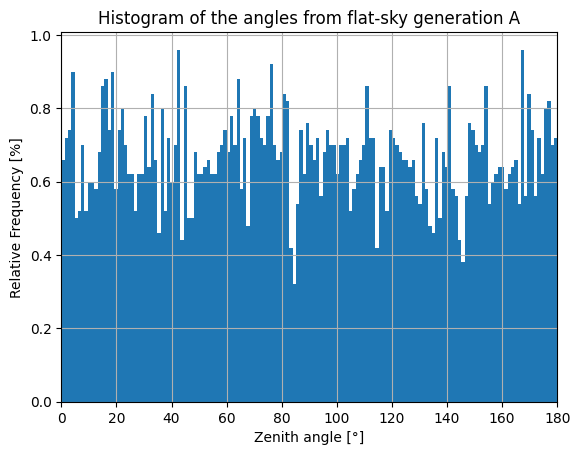

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dati e conversione in gradi
Aangles_plane = np.loadtxt("azimuth_plane.txt")
GRADIA_piano = np.pi - Aangles_plane
GRADIA_piano = np.degrees(GRADIA_piano)
GRADIA_piano = np.abs(GRADIA_piano)

# ==== FREQUENZE RELATIVE ====

# 1) Costruisco istogramma, ma mi prendo i dati numerici
conteggi, bin_edges = np.histogram(GRADIA_piano, bins=150)

# 2) Calcolo le frequenze relative dividendo per il numero totale
totale = len(GRADIA_piano)
frequenze_relative = (conteggi / totale) * 100

# 3) Calcolo il valore medio di ogni intervallo di bin per rappresentarlo sull'asse X
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# 4) Grafico frequenza relativa
plt.bar(bin_centers, frequenze_relative, width=(bin_edges[1]-bin_edges[0]))
plt.title('Histogram of the angles from flat-sky generation A')
plt.xlabel('Azimuth angle [°]')
plt.xlim(0,180)
plt.ylabel('Relative Frequency [%]')
plt.grid(True)
plt.show()


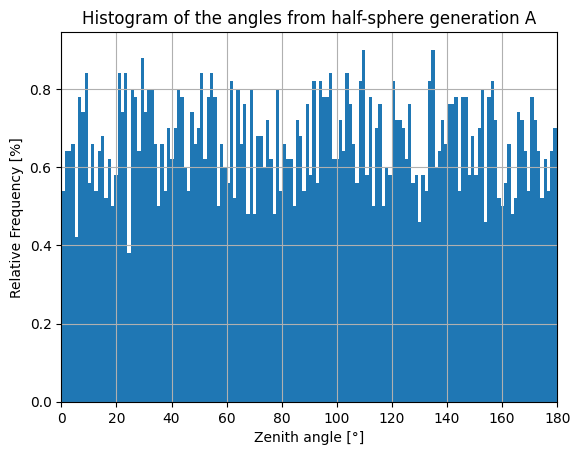

In [ ]:
# Caricamento dati e conversione in gradi
Aangles_sphere = np.loadtxt("azimuth_sphere.txt")
GRADIA_sfera = np.pi - Aangles_sphere
GRADIA_sfera = np.degrees(GRADIA_sfera)
GRADIA_sfera = np.abs(GRADIA_sfera)

# ==== FREQUENZE RELATIVE ====

# 1) Costruisco istogramma, ma mi prendo i dati numerici
conteggi, bin_edges = np.histogram(GRADIA_sfera, bins=150)

# 2) Calcolo le frequenze relative dividendo per il numero totale
totale = len(GRADIA_sfera)
frequenze_relative = (conteggi / totale) *100

# 3) Calcolo il valore medio di ogni intervallo di bin per rappresentarlo sull'asse X
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# 4) Grafico frequenza relativa
plt.bar(bin_centers, frequenze_relative, width=(bin_edges[1]-bin_edges[0]))
plt.title('Histogram of the angles from half-sphere generation A')
plt.xlabel('Azimuth angle [°]')
plt.xlim(0,180)
plt.ylabel('Relative Frequency [%]')
plt.grid(True)
plt.show()